Successfully loaded imagenet pretrained weights from "/home/h8an/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model: osnet_x1_0
- params: 2,193,616
- flops: 978,878,352
torch.Size([1, 512])
torch.Size([12, 512])


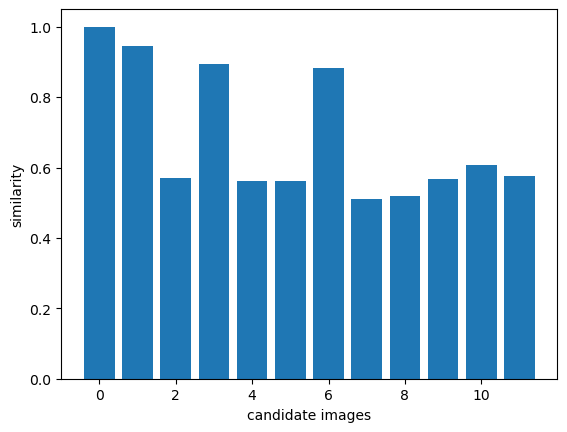

In [8]:
import torchreid
from torchreid.utils import FeatureExtractor
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

extractor = FeatureExtractor(
    model_name='osnet_x1_0',
    model_path='a/b/c/model.pth.tar',
    device='cuda'
)
query_image = [
    './frame0402Person06.png'
]
candidates_image_list = [
    './frame0402Person06.png',
    './frame0403Person05.png',
    './frame0406Person05.png',
    './frame0409Person01.png',
    './frame0410Person03.png',
    './frame0411Person05.png',
    './frame0419Person01.png',
    './frame0420Person05.png',
    './frame0425Person04.png',
    './frame0434Person02.png',
    './frame0439Person04.png',
    './frame0440Person02.png',
]
candidate_features = extractor(candidates_image_list)
query_feature = extractor(query_image)

# query feature
query = query_feature  # [1,512]
print(query.shape)
# gallery features
candidate = candidate_features             # [N,512]
print(candidate.shape)

# cosine similarity
sim = F.cosine_similarity(query, candidate)
sim_np = sim.cpu().detach().numpy()
plt.bar(range(len(candidates_image_list)),sim_np)
plt.xlabel('candidate images')
plt.ylabel('similarity')
plt.show()

In [6]:
torchreid.models.show_avai_models()

['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnext50_32x4d', 'resnext101_32x8d', 'resnet50_fc512', 'se_resnet50', 'se_resnet50_fc512', 'se_resnet101', 'se_resnext50_32x4d', 'se_resnext101_32x4d', 'densenet121', 'densenet169', 'densenet201', 'densenet161', 'densenet121_fc512', 'inceptionresnetv2', 'inceptionv4', 'xception', 'resnet50_ibn_a', 'resnet50_ibn_b', 'nasnsetmobile', 'mobilenetv2_x1_0', 'mobilenetv2_x1_4', 'shufflenet', 'squeezenet1_0', 'squeezenet1_0_fc512', 'squeezenet1_1', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'mudeep', 'resnet50mid', 'hacnn', 'pcb_p6', 'pcb_p4', 'mlfn', 'osnet_x1_0', 'osnet_x0_75', 'osnet_x0_5', 'osnet_x0_25', 'osnet_ibn_x1_0', 'osnet_ain_x1_0', 'osnet_ain_x0_75', 'osnet_ain_x0_5', 'osnet_ain_x0_25']


In [6]:
import sys
print(sys.executable)

/opt/conda/bin/python
